In [28]:
import medmnist
from medmnist import INFO
from medmnist.dataset import PathMNIST

import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader, Subset
from torchvision import transforms

import matplotlib.pyplot as plt

import copy
from sklearn.decomposition import PCA

%matplotlib inline

Download the "pathmnist" dataset (using pre-downloaded version, so download=False).

In [29]:
# Choose dataset
data_flag = 'pathmnist'

# Get dataset info
info = INFO[data_flag]

DataClass = getattr(medmnist, info['python_class'])

# Define transform
transform = transforms.Compose([
    transforms.ToTensor()
])

# Load data
train_dataset = DataClass(split='train', download=False, transform=transform, size=128)
val_dataset = DataClass(split='val', download=False, transform=transform, size=128)
test_dataset = DataClass(split='test', download=False, transform=transform, size=128)

# Load without transform for visualization with imshow
train_imgs = DataClass(split='train', download=False, size=128)

Plot a few sample images.

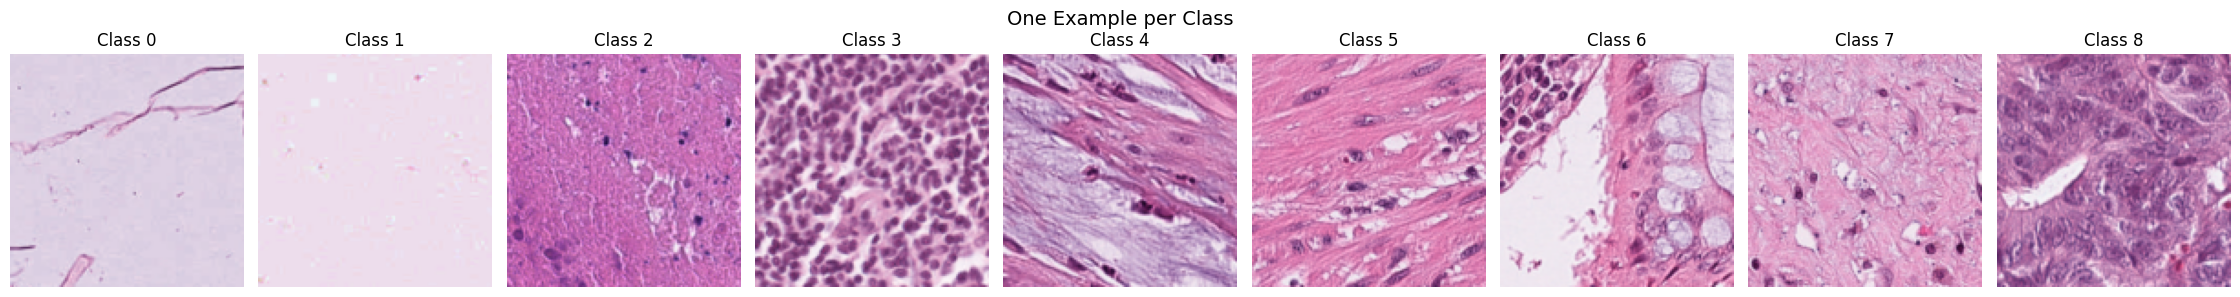

In [30]:
def show_one_per_class(dataset, num_classes=9):

    seen = {}
    
    for i in range(len(dataset)):

        img, label = dataset[i]
        label = label[0]

        if label not in seen:
            seen[label] = img

        if len(seen) == num_classes:
            break

    fig, axes = plt.subplots(1, num_classes, figsize=(2.5 * num_classes, 3))

    for cls in range(num_classes):
        img = seen[cls]

        # Convert tensor -> numpy image
        if isinstance(img, torch.Tensor):
            img = img.permute(1, 2, 0).numpy()

        axes[cls].imshow(img)
        axes[cls].set_title(f"Class {cls}")
        axes[cls].axis("off")

    plt.suptitle("One Example per Class", fontsize=14)
    plt.tight_layout()
    plt.show()

show_one_per_class(train_imgs)

In [31]:
# Define data loaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

## Objective

## Variational Autoencoder

### Architecture

In [32]:
class ConvVAE(nn.Module):
    def __init__(self, in_channels=3, latent_dim=64):
        super().__init__()
        self.latent_dim = latent_dim

        self.encoder_cnn = nn.Sequential(
            nn.Conv2d(in_channels, 32, 4, 2, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, 4, 2, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 256, 4, 2, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 512, 4, 2, 1),
            nn.ReLU(inplace=True),
        )

        self.flatten_dim = 512 * 4 * 4

        self.fc_mu = nn.Linear(self.flatten_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.flatten_dim, latent_dim)

        self.decoder_fc = nn.Linear(latent_dim, self.flatten_dim)

        self.decoder_cnn = nn.Sequential(
            nn.ConvTranspose2d(512, 256, 4, 2, 1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32, in_channels, 4, 2, 1),
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder_cnn(x)
        h = torch.flatten(h, start_dim=1)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.decoder_fc(z)
        h = h.view(-1, 512, 4, 4)
        return self.decoder_cnn(h)

    def forward(self, x, deterministic=False):
        mu, logvar = self.encode(x)
        z = mu if deterministic else self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar

### Fit

In [33]:
# Sample a small subset of images for training
small_train = Subset(train_dataset, range(500))
small_val   = Subset(val_dataset, range(200))

train_loader_small = DataLoader(
    small_train,
    batch_size=8,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader_small = DataLoader(
    small_val,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [34]:
def vae_loss(recon, x, mu, logvar, beta=1e-3):
    recon_loss = F.mse_loss(recon, x, reduction="mean")
    kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    total_loss = recon_loss + beta * kl_loss
    return total_loss, recon_loss, kl_loss

def get_beta(epoch, warmup_epochs=10, beta_max=1e-3):
    if epoch >= warmup_epochs:
        return beta_max
    return beta_max * (epoch / warmup_epochs)

def train_one_epoch(model, loader, optimizer, device, beta):
    model.train()

    total_loss = 0.0
    total_recon = 0.0
    total_kl = 0.0

    for x, _ in loader:
        x = x.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        recon, mu, logvar = model(x)

        loss, recon_loss, kl_loss = vae_loss(recon, x, mu, logvar, beta=beta)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_recon += recon_loss.item()
        total_kl += kl_loss.item()

    n_batches = len(loader)
    return {
        "loss": total_loss / n_batches,
        "recon": total_recon / n_batches,
        "kl": total_kl / n_batches,
    }

@torch.no_grad()
def evaluate(model, loader, device, beta):
    model.eval()

    total_loss = 0.0
    total_recon = 0.0
    total_kl = 0.0

    for x, _ in loader:
        x = x.to(device, non_blocking=True)

        recon, mu, logvar = model(x)
        loss, recon_loss, kl_loss = vae_loss(recon, x, mu, logvar, beta=beta)

        total_loss += loss.item()
        total_recon += recon_loss.item()
        total_kl += kl_loss.item()

    n_batches = len(loader)
    return {
        "loss": total_loss / n_batches,
        "recon": total_recon / n_batches,
        "kl": total_kl / n_batches,
    }

device = torch.device("mps" if torch.mps.is_available() else "cpu")
print("Device:", device)

vae_model = ConvVAE(in_channels=3, latent_dim=64).to(device)
optimizer = torch.optim.Adam(vae_model.parameters(), lr=1e-3)

num_epochs = 25
best_val_loss = float("inf")
best_state = None

history = {
    "train_loss": [],
    "train_recon": [],
    "train_kl": [],
    "val_loss": [],
    "val_recon": [],
    "val_kl": [],
    "beta": []
}

for epoch in range(num_epochs):

    beta = get_beta(epoch, warmup_epochs=10, beta_max=1e-3)

    train_metrics = train_one_epoch(vae_model, train_loader_small, optimizer, device, beta)
    val_metrics = evaluate(vae_model, val_loader_small, device, beta)

    history["train_loss"].append(train_metrics["loss"])
    history["train_recon"].append(train_metrics["recon"])
    history["train_kl"].append(train_metrics["kl"])
    history["val_loss"].append(val_metrics["loss"])
    history["val_recon"].append(val_metrics["recon"])
    history["val_kl"].append(val_metrics["kl"])
    history["beta"].append(beta)

    print(
        f"Epoch {epoch+1:02d}/{num_epochs} | "
        f"beta={beta:.6f} | "
        f"train_loss={train_metrics['loss']:.4f} | "
        f"train_recon={train_metrics['recon']:.4f} | "
        f"train_kl={train_metrics['kl']:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_recon={val_metrics['recon']:.4f} | "
        f"val_kl={val_metrics['kl']:.4f}"
    )

    if val_metrics["loss"] < best_val_loss:
        best_val_loss = val_metrics["loss"]
        best_state = copy.deepcopy(vae_model.state_dict())

if best_state is not None:
    vae_model.load_state_dict(best_state)

Device: mps


/Users/zachquicksall/Documents/projects/data-science-portfolio/medmnist/venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch 01/25 | beta=0.000000 | train_loss=0.0427 | train_recon=0.0427 | train_kl=178.4363 | val_loss=0.0347 | val_recon=0.0347 | val_kl=0.0001
Epoch 02/25 | beta=0.000100 | train_loss=0.0296 | train_recon=0.0295 | train_kl=0.7608 | val_loss=0.0238 | val_recon=0.0237 | val_kl=0.7833
Epoch 03/25 | beta=0.000200 | train_loss=0.0237 | train_recon=0.0235 | train_kl=0.9772 | val_loss=0.0232 | val_recon=0.0231 | val_kl=0.6118
Epoch 04/25 | beta=0.000300 | train_loss=0.0226 | train_recon=0.0224 | train_kl=0.7069 | val_loss=0.0221 | val_recon=0.0219 | val_kl=0.7137
Epoch 05/25 | beta=0.000400 | train_loss=0.0222 | train_recon=0.0220 | train_kl=0.6449 | val_loss=0.0206 | val_recon=0.0205 | val_kl=0.4495
Epoch 06/25 | beta=0.000500 | train_loss=0.0211 | train_recon=0.0208 | train_kl=0.5818 | val_loss=0.0198 | val_recon=0.0194 | val_kl=0.7207
Epoch 07/25 | beta=0.000600 | train_loss=0.0202 | train_recon=0.0198 | train_kl=0.6711 | val_loss=0.0195 | val_recon=0.0193 | val_kl=0.4562
Epoch 08/25 | beta

### Reconstruction

In [35]:
@torch.no_grad()
def show_vae_reconstructions(model, loader, device, n=6, title="Reconstructions"):
    model.eval()
    
    x, _ = next(iter(loader))
    x = x.to(device)
    
    recon, mu, logvar = model(x)
    
    x = x[:n].cpu().permute(0, 2, 3, 1).numpy()
    recon = recon[:n].cpu().permute(0, 2, 3, 1).numpy()
    
    fig, axes = plt.subplots(2, n, figsize=(2.5 * n, 5))
    fig.suptitle(title, fontsize=14)
    
    for i in range(n):
        axes[0, i].imshow(x[i])
        axes[0, i].axis("off")
        axes[0, i].set_title("Original")
        
        axes[1, i].imshow(recon[i])
        axes[1, i].axis("off")
        axes[1, i].set_title("Recon")
    
    plt.tight_layout()
    plt.show()

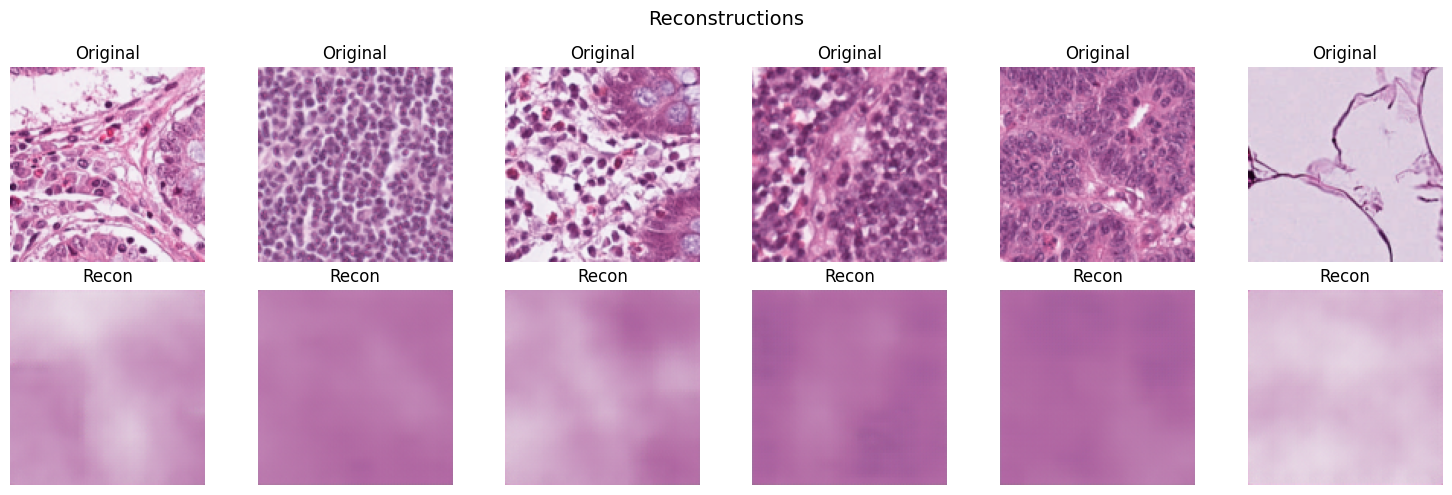

In [36]:
show_vae_reconstructions(vae_model, train_loader_small, device, n = 6)

### Latent Space

In [37]:
@torch.no_grad()
def extract_vae_latents(model, loader, device):
    model.eval()
    latents, labels = [], []

    for x, y in loader:
        x = x.to(device)
        mu, logvar = model.encode(x)

        latents.append(mu.cpu().numpy())
        labels.append(y.cpu().numpy())

    return np.concatenate(latents), np.concatenate(labels).squeeze()

def plot_pca(latents, labels, title):
    pca = PCA(n_components=2)
    z = pca.fit_transform(latents)

    plt.figure(figsize=(7, 6))
    scatter = plt.scatter(
        z[:, 0],
        z[:, 1],
        c=labels,
        s=15,
        alpha=0.8
    )
    plt.colorbar(scatter, label="Class label")
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
    plt.title(title)
    plt.tight_layout()
    plt.show()

    #return z, pca

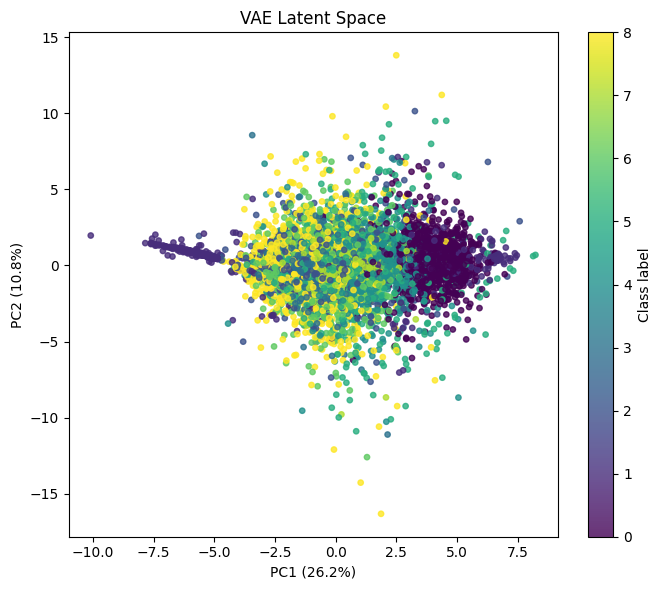

In [38]:
vae_latents, vae_labels = extract_vae_latents(vae_model, val_loader, device)
plot_pca(vae_latents, vae_labels, "VAE Latent Space")

#### Interpretation

The latent space learned by the VAE exhibits a smooth, continuous structure rather than clearly separated clusters. While samples from different classes overlap substantially, there is evidence of gradual transitions across the embedding, suggesting that the model organizes images along continuous feature axes rather than discrete categories.

The latent space learned by the VAE exhibits a smooth, continuous structure rather than clearly separated clusters. While samples from different classes overlap substantially, there is evidence of gradual transitions across the embedding, suggesting that the model organizes images along continuous feature axes rather than discrete categories.

#### Key takeaway

> The VAE learns a structured and smooth latent manifold, but not one that strongly aligns with class labels.

## Autoencoder

### Architecture

In [39]:
class ConvAE(nn.Module):
    def __init__(self, in_channels=3, latent_dim=64):
        super().__init__()
        self.latent_dim = latent_dim

        self.encoder_cnn = nn.Sequential(
            nn.Conv2d(in_channels, 32, 4, 2, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, 4, 2, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 256, 4, 2, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 512, 4, 2, 1),
            nn.ReLU(inplace=True),
        )

        self.flatten_dim = 512 * 4 * 4

        self.encoder_fc = nn.Linear(self.flatten_dim, latent_dim)
        self.decoder_fc = nn.Linear(latent_dim, self.flatten_dim)

        self.decoder_cnn = nn.Sequential(
            nn.ConvTranspose2d(512, 256, 4, 2, 1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32, in_channels, 4, 2, 1),
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder_cnn(x)
        h = torch.flatten(h, start_dim=1)
        z = self.encoder_fc(h)
        return z

    def decode(self, z):
        h = self.decoder_fc(z)
        h = h.view(-1, 512, 4, 4)
        return self.decoder_cnn(h)

    def forward(self, x):
        z = self.encode(x)
        recon = self.decode(z)
        return recon, z
    
def recon_loss(recon, x):
    return F.l1_loss(recon, x, reduction="mean")

### Fit

In [40]:
ae_model = ConvAE(in_channels=3, latent_dim=64).to(device)
ae_optimizer = torch.optim.Adam(ae_model.parameters(), lr=1e-3)

num_epochs = 25
best_ae_val_loss = float("inf")
best_ae_state = None

ae_history = {
    "train_loss": [],
    "val_loss": []
}

for epoch in range(num_epochs):
    ae_model.train()
    train_loss = 0.0

    for x, _ in train_loader_small:
        x = x.to(device)

        ae_optimizer.zero_grad()

        recon, z = ae_model(x)
        loss = F.l1_loss(recon, x, reduction="mean")

        loss.backward()
        ae_optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader_small)

    ae_model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for x, _ in val_loader_small:
            x = x.to(device)

            recon, z = ae_model(x)
            loss = F.l1_loss(recon, x, reduction="mean")

            val_loss += loss.item()

    val_loss /= len(val_loader_small)

    ae_history["train_loss"].append(train_loss)
    ae_history["val_loss"].append(val_loss)

    print(
        f"Epoch {epoch+1:02d}/{num_epochs} | "
        f"AE train_l1={train_loss:.4f} | "
        f"AE val_l1={val_loss:.4f}"
    )

    if val_loss < best_ae_val_loss:
        best_ae_val_loss = val_loss
        best_ae_state = copy.deepcopy(ae_model.state_dict())

if best_ae_state is not None:
    ae_model.load_state_dict(best_ae_state)

/Users/zachquicksall/Documents/projects/data-science-portfolio/medmnist/venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch 01/25 | AE train_l1=0.1492 | AE val_l1=0.1346
Epoch 02/25 | AE train_l1=0.1246 | AE val_l1=0.1184
Epoch 03/25 | AE train_l1=0.1163 | AE val_l1=0.1145
Epoch 04/25 | AE train_l1=0.1114 | AE val_l1=0.1160
Epoch 05/25 | AE train_l1=0.1100 | AE val_l1=0.1008
Epoch 06/25 | AE train_l1=0.1008 | AE val_l1=0.0996
Epoch 07/25 | AE train_l1=0.0965 | AE val_l1=0.0975
Epoch 08/25 | AE train_l1=0.0999 | AE val_l1=0.0971
Epoch 09/25 | AE train_l1=0.1004 | AE val_l1=0.1018
Epoch 10/25 | AE train_l1=0.0952 | AE val_l1=0.0982
Epoch 11/25 | AE train_l1=0.0950 | AE val_l1=0.0955
Epoch 12/25 | AE train_l1=0.0934 | AE val_l1=0.0958
Epoch 13/25 | AE train_l1=0.0936 | AE val_l1=0.0967
Epoch 14/25 | AE train_l1=0.0918 | AE val_l1=0.0943
Epoch 15/25 | AE train_l1=0.0937 | AE val_l1=0.0976
Epoch 16/25 | AE train_l1=0.0906 | AE val_l1=0.0964
Epoch 17/25 | AE train_l1=0.0920 | AE val_l1=0.0968
Epoch 18/25 | AE train_l1=0.0943 | AE val_l1=0.0988
Epoch 19/25 | AE train_l1=0.0909 | AE val_l1=0.0936
Epoch 20/25 

### Reconstruction

In [41]:
@torch.no_grad()
def show_ae_reconstructions(model, loader, device, n=6):
    model.eval()

    x, _ = next(iter(loader))
    x = x[:n].to(device)

    recon, z = model(x)

    x = x.cpu().permute(0, 2, 3, 1).numpy()
    recon = recon.cpu().permute(0, 2, 3, 1).numpy()

    fig, axes = plt.subplots(2, n, figsize=(2.5*n, 5))
    fig.suptitle("AE Reconstructions")

    for i in range(n):
        axes[0, i].imshow(x[i])
        axes[0, i].axis("off")
        axes[0, i].set_title("Original")

        axes[1, i].imshow(recon[i])
        axes[1, i].axis("off")
        axes[1, i].set_title("Recon")

    plt.tight_layout()
    plt.show()

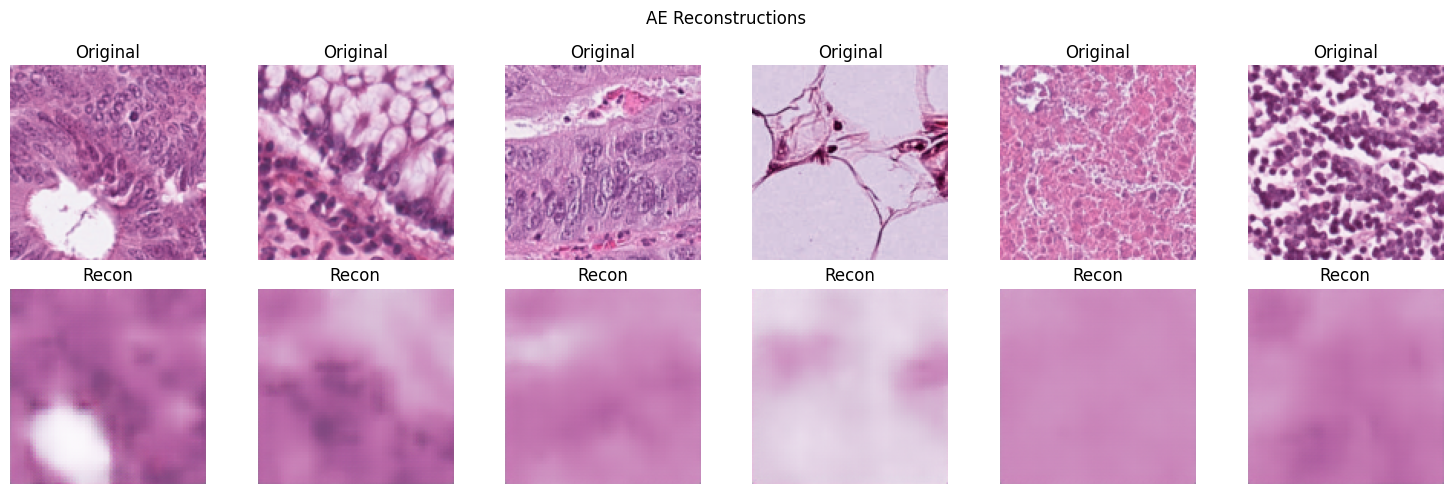

In [42]:
show_ae_reconstructions(ae_model, train_loader_small, device, n = 6)

### Latent Space

In [43]:
@torch.no_grad()
def extract_ae_latents(model, loader, device):
    model.eval()
    latents, labels = [], []

    for x, y in loader:
        x = x.to(device)
        z = model.encode(x)

        latents.append(z.cpu().numpy())
        labels.append(y.cpu().numpy())

    return np.concatenate(latents), np.concatenate(labels).squeeze()

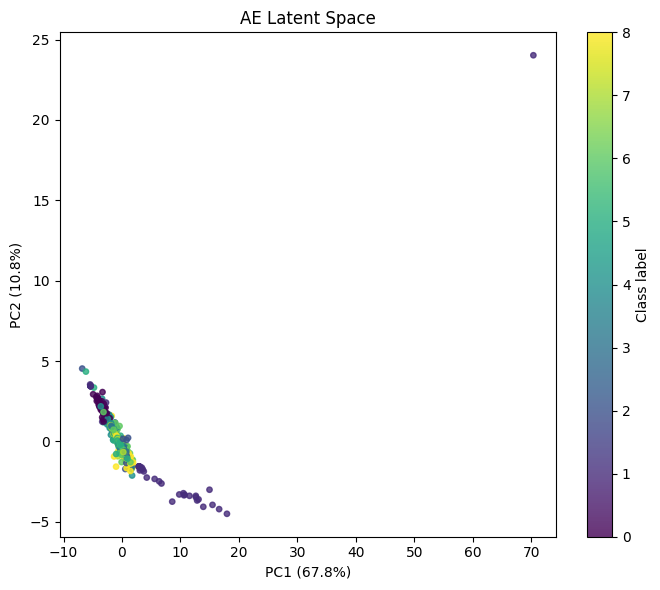

In [44]:
ae_latents, ae_labels = extract_ae_latents(ae_model, train_loader_small, device)
plot_pca(ae_latents, ae_labels, "AE Latent Space")

#### Interpretation

The latent space of the standard autoencoder appears less structured than that of the VAE. While some local grouping of samples may be present, the overall distribution is more irregular and lacks the smooth continuity observed in the VAE embedding.

Because the autoencoder is trained solely to minimize reconstruction error without any constraint on the latent distribution, it is free to encode information in an arbitrary way. This results in a latent space that may capture useful features for reconstruction but does not organize them in a globally meaningful or interpretable structure.

Some local grouping suggests that the autoencoder partially captures class-related features despite lacking explicit structure.

#### Key takeaway

> The AE learns a useful but unstructured latent representation, optimized for reconstruction rather than interpretability. Although, per the sampled reconstructions, this model is largely undertrained.

## U-Net Autoencoder

### Architecture

In [45]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UNetAE(nn.Module):
    def __init__(self, in_channels=3, out_channels=3):
        super().__init__()

        self.pool = nn.MaxPool2d(2)

        self.enc1 = ConvBlock(in_channels, 32)
        self.enc2 = ConvBlock(32, 64)
        self.enc3 = ConvBlock(64, 128)
        self.enc4 = ConvBlock(128, 256)

        self.bottleneck = ConvBlock(256, 512)

        self.up4 = nn.ConvTranspose2d(512, 256, 2, 2)
        self.dec4 = ConvBlock(512, 256)

        self.up3 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.dec3 = ConvBlock(256, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.dec2 = ConvBlock(128, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, 2, 2)
        self.dec1 = ConvBlock(64, 32)

        self.final = nn.Sequential(
            nn.Conv2d(32, out_channels, 1),
            nn.Sigmoid()
        )

    def encode(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b = self.bottleneck(self.pool(e4))
        return b

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        b = self.bottleneck(self.pool(e4))

        d4 = self.up4(b)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.final(d1)

### Fit

In [46]:
unet_model = UNetAE(in_channels=3, out_channels=3).to(device)
unet_optimizer = torch.optim.Adam(unet_model.parameters(), lr=1e-3)

num_epochs = 25
best_unet_val_loss = float("inf")
best_unet_state = None

unet_history = {
    "train_loss": [],
    "val_loss": []
}

for epoch in range(num_epochs):
    unet_model.train()
    train_loss = 0.0

    for x, _ in train_loader_small:
        x = x.to(device)

        unet_optimizer.zero_grad()

        recon = unet_model(x)
        loss = F.l1_loss(recon, x, reduction="mean")

        loss.backward()
        unet_optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader_small)

    unet_model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for x, _ in val_loader_small:
            x = x.to(device)

            recon = unet_model(x)
            loss = F.l1_loss(recon, x, reduction="mean")

            val_loss += loss.item()

    val_loss /= len(val_loader_small)

    unet_history["train_loss"].append(train_loss)
    unet_history["val_loss"].append(val_loss)

    print(
        f"Epoch {epoch+1:02d}/{num_epochs} | "
        f"U-Net train_l1={train_loss:.4f} | "
        f"U-Net val_l1={val_loss:.4f}"
    )

    if val_loss < best_unet_val_loss:
        best_unet_val_loss = val_loss
        best_unet_state = copy.deepcopy(unet_model.state_dict())

if best_unet_state is not None:
    unet_model.load_state_dict(best_unet_state)

/Users/zachquicksall/Documents/projects/data-science-portfolio/medmnist/venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch 01/25 | U-Net train_l1=0.1215 | U-Net val_l1=0.0864
Epoch 02/25 | U-Net train_l1=0.0569 | U-Net val_l1=0.0397
Epoch 03/25 | U-Net train_l1=0.0350 | U-Net val_l1=0.0347
Epoch 04/25 | U-Net train_l1=0.0314 | U-Net val_l1=0.0258
Epoch 05/25 | U-Net train_l1=0.0297 | U-Net val_l1=0.0247
Epoch 06/25 | U-Net train_l1=0.0253 | U-Net val_l1=0.0268
Epoch 07/25 | U-Net train_l1=0.0233 | U-Net val_l1=0.0215
Epoch 08/25 | U-Net train_l1=0.0215 | U-Net val_l1=0.0187
Epoch 09/25 | U-Net train_l1=0.0182 | U-Net val_l1=0.0189
Epoch 10/25 | U-Net train_l1=0.0176 | U-Net val_l1=0.0164
Epoch 11/25 | U-Net train_l1=0.0165 | U-Net val_l1=0.0184
Epoch 12/25 | U-Net train_l1=0.0178 | U-Net val_l1=0.0205
Epoch 13/25 | U-Net train_l1=0.0167 | U-Net val_l1=0.0139
Epoch 14/25 | U-Net train_l1=0.0161 | U-Net val_l1=0.0142
Epoch 15/25 | U-Net train_l1=0.0139 | U-Net val_l1=0.0130
Epoch 16/25 | U-Net train_l1=0.0139 | U-Net val_l1=0.0123
Epoch 17/25 | U-Net train_l1=0.0129 | U-Net val_l1=0.0183
Epoch 18/25 | 

### Reconstruction

In [47]:
@torch.no_grad()
def show_unet_reconstructions(model, loader, device, n=6):
    model.eval()

    x, _ = next(iter(loader))
    x = x[:n].to(device)

    recon = model(x)

    x = x.cpu().permute(0, 2, 3, 1).numpy()
    recon = recon.cpu().permute(0, 2, 3, 1).numpy()

    fig, axes = plt.subplots(2, n, figsize=(2.5*n, 5))
    fig.suptitle("U-Net Reconstructions")

    for i in range(n):
        axes[0, i].imshow(x[i])
        axes[0, i].axis("off")
        axes[0, i].set_title("Original")

        axes[1, i].imshow(recon[i])
        axes[1, i].axis("off")
        axes[1, i].set_title("Recon")

    plt.tight_layout()
    plt.show()

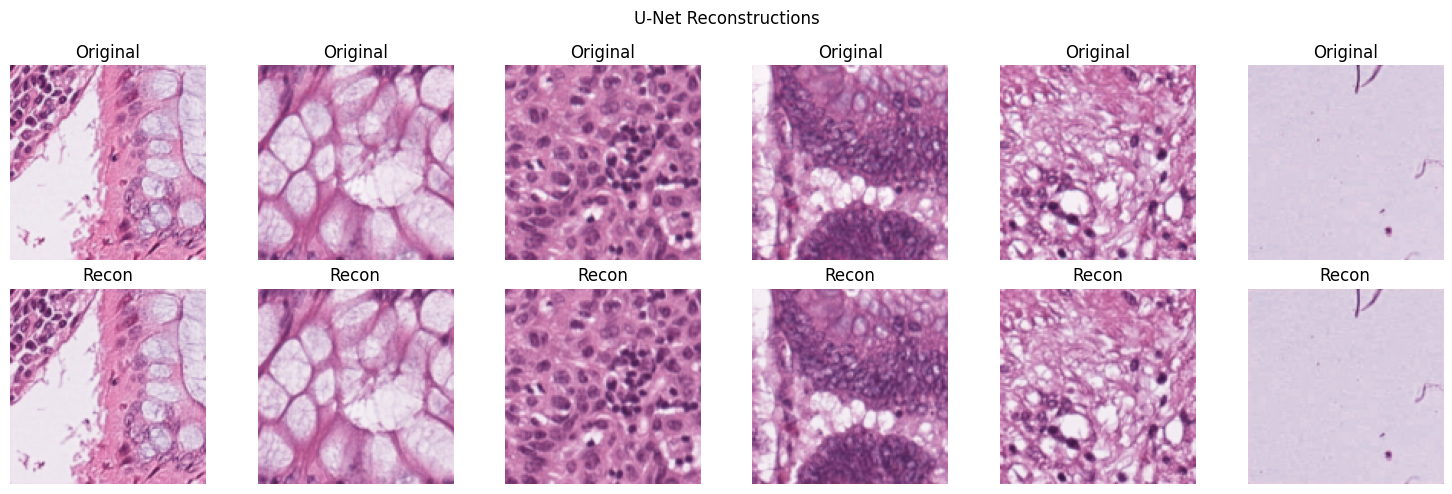

In [48]:
show_unet_reconstructions(unet_model, train_loader_small, device, n = 6)

### Latent Space

In [49]:
@torch.no_grad()
def extract_unet_latents(model, loader, device):
    model.eval()
    latents, labels = [], []

    for x, y in loader:
        x = x.to(device)
        b = model.encode(x)

        z = F.adaptive_avg_pool2d(b, output_size=1)
        z = z.flatten(start_dim=1)

        latents.append(z.cpu().numpy())
        labels.append(y.cpu().numpy())

    return np.concatenate(latents), np.concatenate(labels).squeeze()

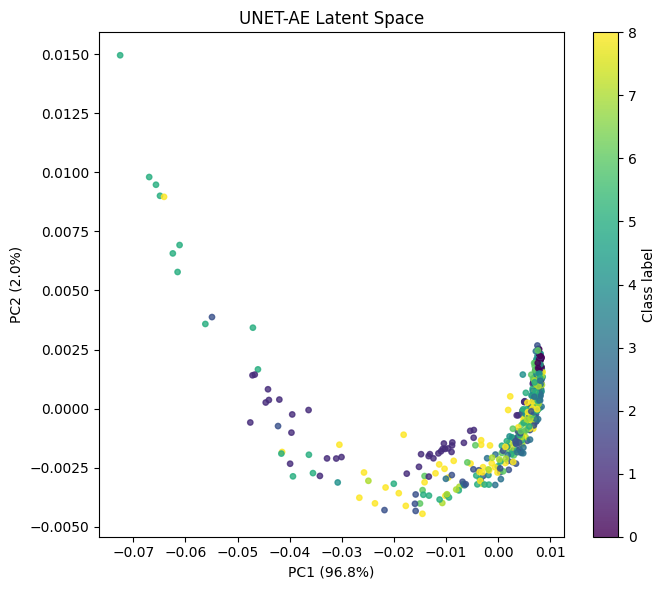

In [50]:
unet_latents, unet_labels = extract_unet_latents(unet_model, train_loader_small, device)
plot_pca(unet_latents, unet_labels, "UNET-AE Latent Space")

#### Interpretation

The latent representations extracted from the U-Net autoencoder show little coherent structure in the PCA projection. Points tend to be widely dispersed with minimal clustering or organization by class.

This is expected, as the U-Net architecture relies heavily on skip connections that allow spatial information to bypass the bottleneck. As a result, the model is not forced to encode meaningful global information in its bottleneck representation. Instead, the bottleneck features act more as intermediate activations rather than a compact latent representation.

#### Key takeaway

> The U-Net does not learn a meaningful compressed latent space, because it does not need to do so.

## Comparison

In [51]:
@torch.no_grad()
def show_three_model_comparison(
    vae_model,
    ae_model,
    unet_model,
    loader,
    device,
    n=6
):
    vae_model.eval()
    ae_model.eval()
    unet_model.eval()

    x, _ = next(iter(loader))
    x = x[:n].to(device)

    # VAE reconstruction
    vae_recon, mu, logvar = vae_model(x, deterministic=True)

    # AE reconstruction
    ae_recon, z = ae_model(x)

    # U-Net reconstruction
    unet_recon = unet_model(x)

    # Convert to image format
    x_np = x.cpu().permute(0, 2, 3, 1).numpy()
    vae_np = vae_recon.cpu().permute(0, 2, 3, 1).numpy()
    ae_np = ae_recon.cpu().permute(0, 2, 3, 1).numpy()
    unet_np = unet_recon.cpu().permute(0, 2, 3, 1).numpy()

    fig, axes = plt.subplots(4, n, figsize=(2.5 * n, 10))
    fig.suptitle("Reconstruction Comparison: VAE vs AE vs U-Net", fontsize=16)

    row_titles = ["Original", "VAE", "AE", "U-Net"]

    images = [x_np, vae_np, ae_np, unet_np]

    for row in range(4):
        for col in range(n):
            axes[row, col].imshow(images[row][col])
            axes[row, col].axis("off")

            if col == 0:
                axes[row, col].set_ylabel(
                    row_titles[row],
                    fontsize=12,
                    rotation=0,
                    labelpad=40,
                    va="center"
                )

    plt.tight_layout()
    plt.show()

/Users/zachquicksall/Documents/projects/data-science-portfolio/medmnist/venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


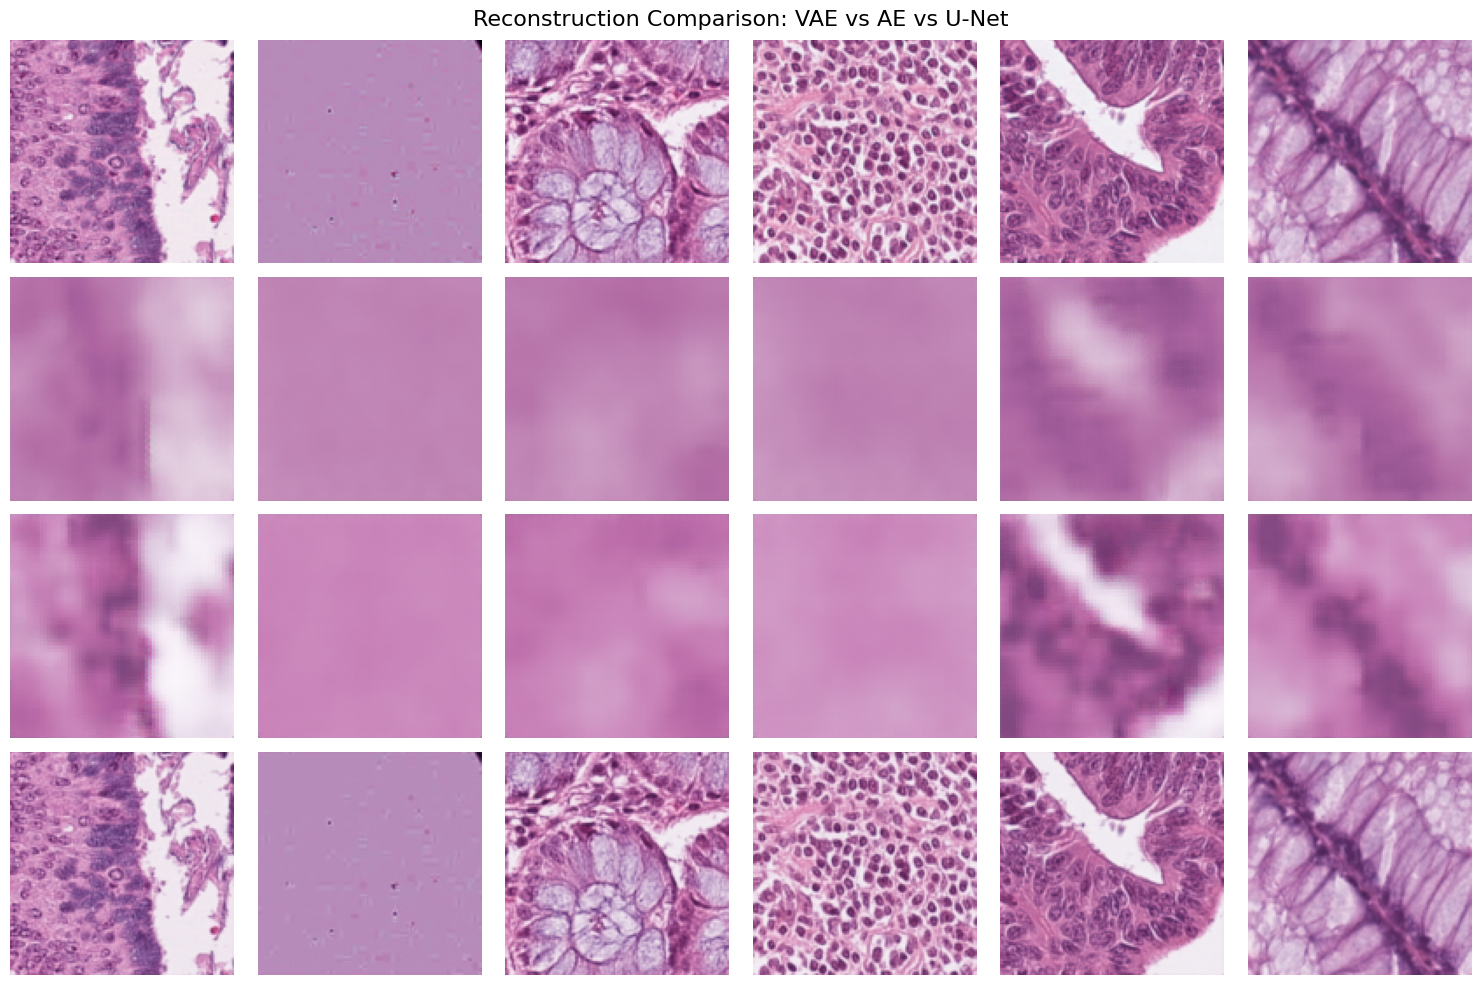

In [52]:
show_three_model_comparison(
    vae_model=vae_model,
    ae_model=ae_model,
    unet_model=unet_model,
    loader=train_loader_small,
    device=device,
    n=6
)

Comparing the three models highlights a clear tradeoff between reconstruction fidelity and latent space structure. The VAE produces the most organized and smooth latent space but at the cost of reconstruction sharpness. The standard autoencoder can improve reconstruction quality with additional training, but yields a less structured latent space. The U-Net achieves the best reconstruction performance due to its skip connections, but its bottleneck representation lacks meaningful structure.

These results demonstrate that architectural and objective design choices strongly influence what information is preserved and how it is represented. Models that enforce constraints on the latent space (e.g., VAEs) produce more interpretable representations, while models focused purely on reconstruction (e.g., U-Net) prioritize visual fidelity over representation structure.